In [ ]:
import sys
import os
import torch

sys.path.append(os.path.abspath("../../U-TAE_models"))
from src.backbones.utae import UTAE

model = UTAE(
    input_dim=10,
    encoder_widths=[64, 64, 64, 128],
    decoder_widths=[32, 32, 64, 128],
    n_head=16,
    d_model=256,
    return_maps=False
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

weights_path = "../../utae_pastis_v1.pth" 

try:
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()
    print(f"модель загружена на: {device}")
except FileNotFoundError:
    print(f"ошибка: не нашел файл весов по пути {weights_path}")

модель загружена на: cuda


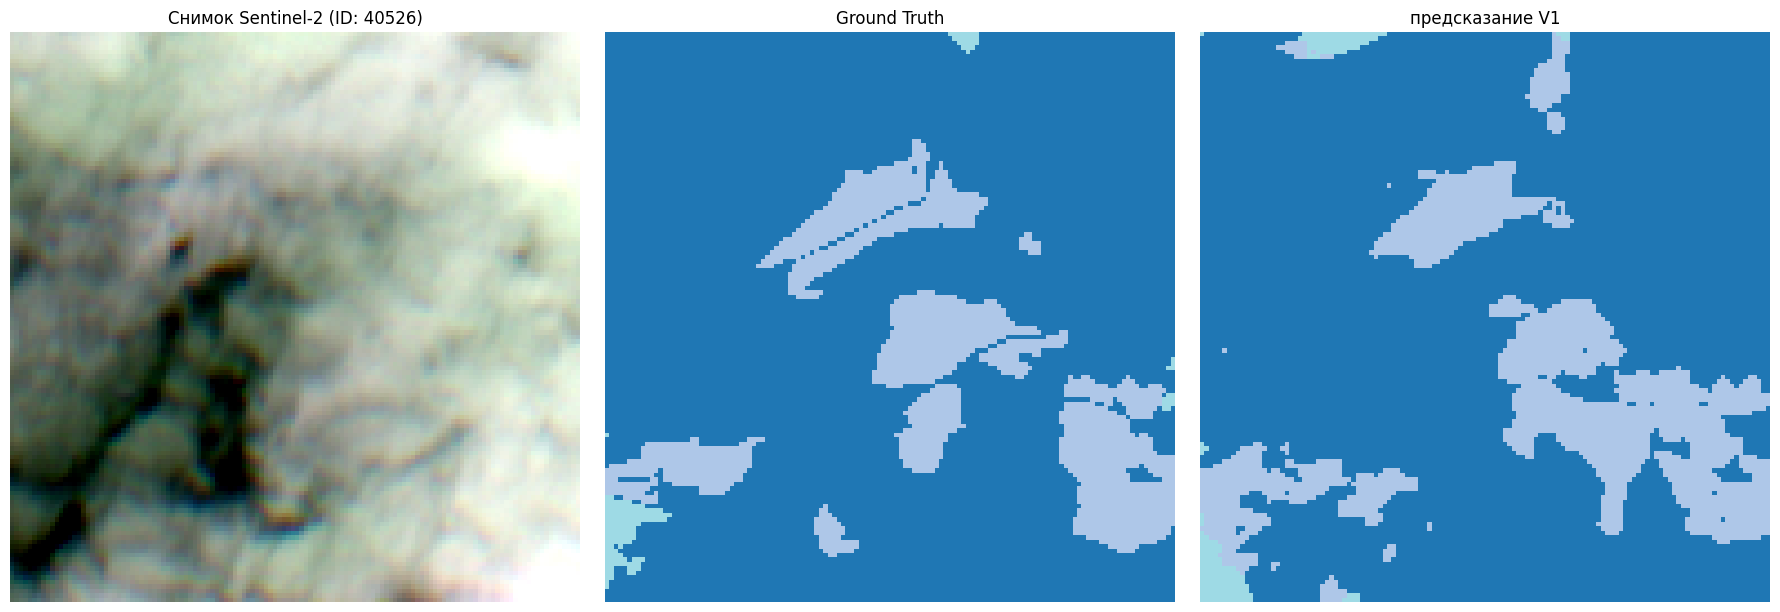

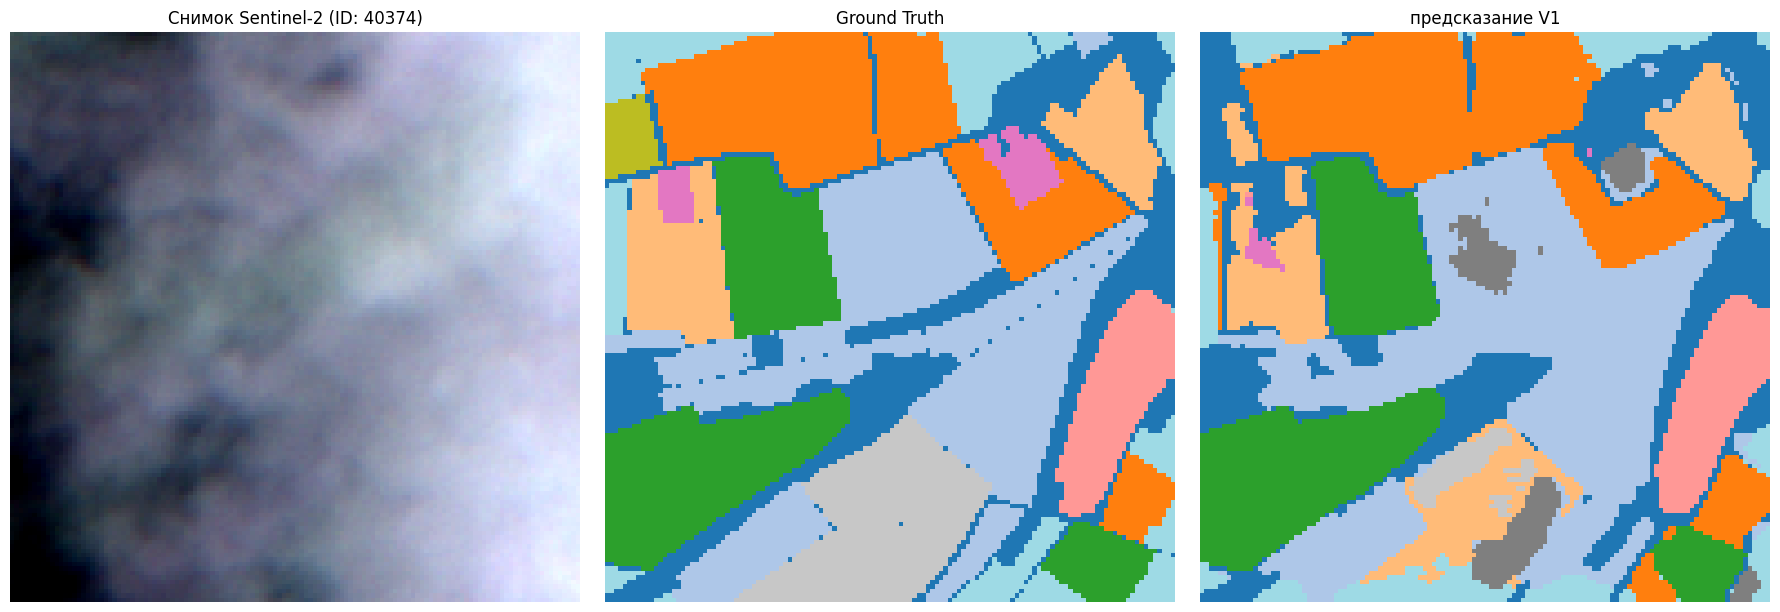

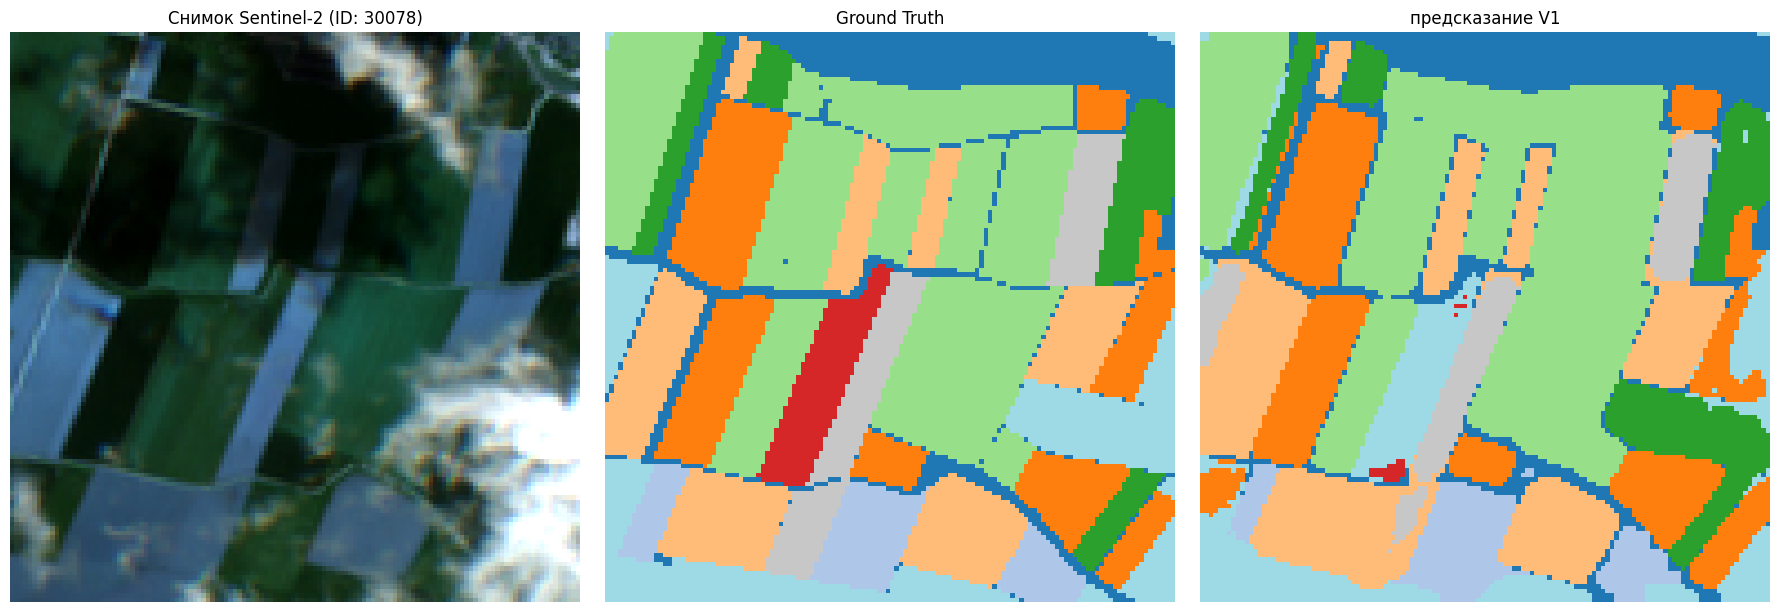

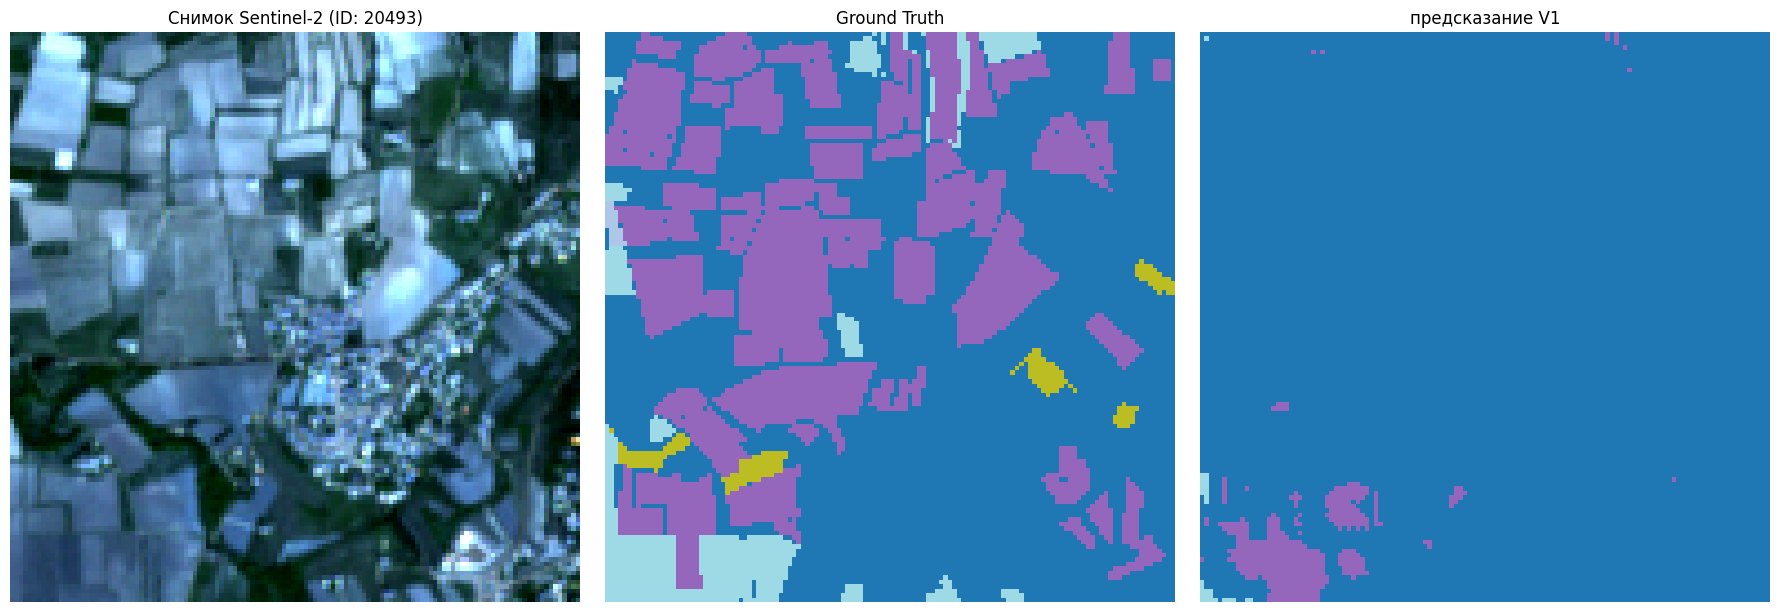

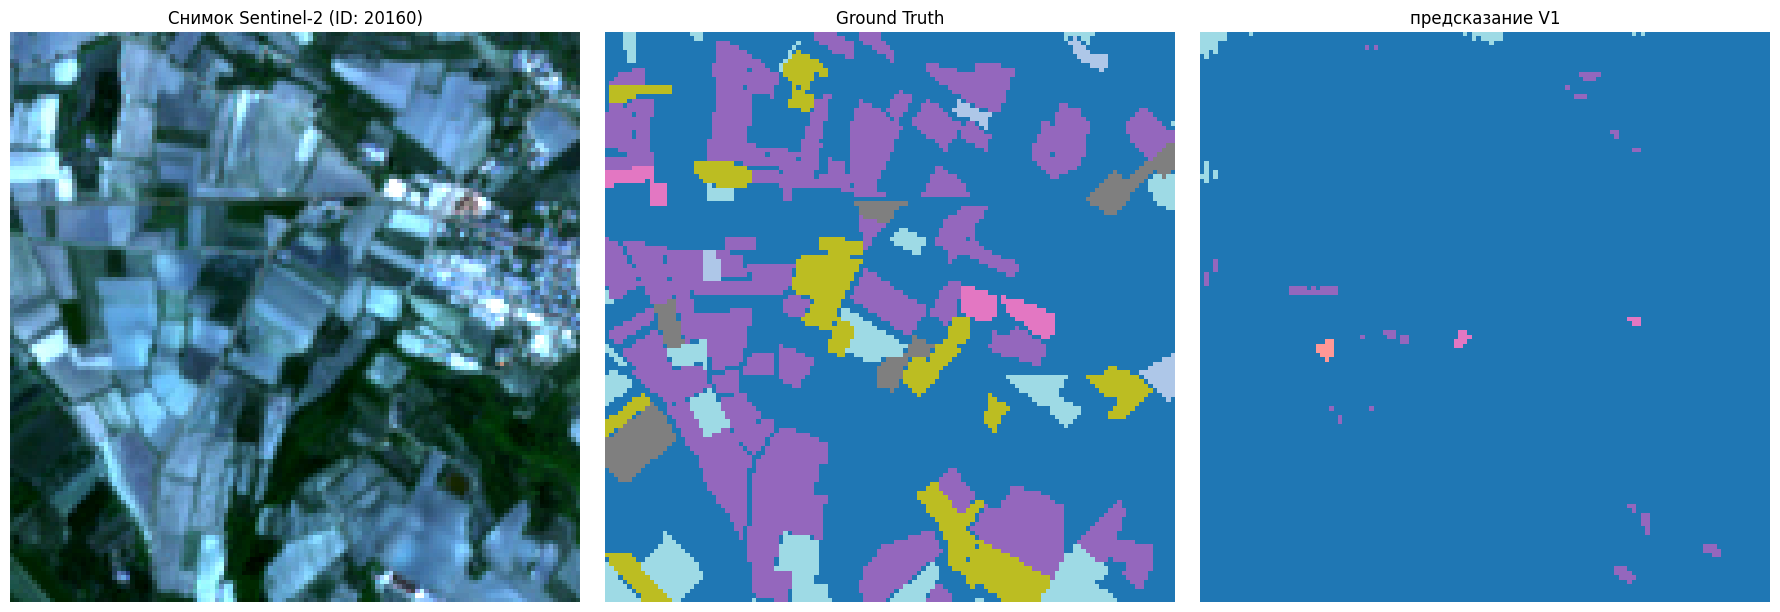

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

def visualize_geosynth_result(patch_id, model, device):
    data_path = f"../../PastisSampleData/DATA_S2/S2_{patch_id}.npy"
    mask_path = f"../../PastisSampleData/ANNOTATIONS/TARGET_{patch_id}.npy"
    
    if not os.path.exists(data_path):
        print(f"Ошибка: Файл {data_path} не найден!")
        return

    raw_data = np.load(data_path)
    raw_mask = np.load(mask_path)

    if raw_mask.ndim == 3:
        raw_mask = raw_mask[0]

    image_tensor = torch.from_numpy(raw_data).float()
    
    T = image_tensor.shape[0]
    batch_positions = torch.arange(T).float().to(device)
    
    model.eval()
    with torch.no_grad():
        input_data = image_tensor.unsqueeze(0).to(device)
        output = model(input_data, batch_positions=batch_positions)
        prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    rgb = image_tensor[image_tensor.shape[0]//2, :3, :, :].permute(1, 2, 0).numpy()
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb_viz = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)
    
    ax[0].imshow(rgb_viz)
    ax[0].set_title(f"Снимок Sentinel-2 (ID: {patch_id})")
    ax[0].axis('off')
    
    ax[1].imshow(raw_mask, cmap='tab20', interpolation='nearest')
    ax[1].set_title("Ground Truth")
    ax[1].axis('off')
    
    ax[2].imshow(prediction, cmap='tab20', interpolation='nearest')
    ax[2].set_title(f"предсказание V1")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_geosynth_result('40526', model, device)
visualize_geosynth_result('40374', model, device)
visualize_geosynth_result('30078', model, device)
visualize_geosynth_result('20493', model, device)
visualize_geosynth_result('20160', model, device)